<a href="https://colab.research.google.com/github/alyamman-alsaad/plantHealth_YOLOv8/blob/main/plantDisease_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install ultralytics

In [44]:
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

In [26]:
# Call to resize and quantize imgs for inputs to int8 tflite model
class QuantizedImageGenerator:
    """
    Generator that loads images and quantizes them for int8 TFLite models.

    Quantization formula: float_value = scale * (quantized_value + 128)
    """

    def __init__(self, data_dir, batch_size=30, image_size=(96, 96),
                 scale=0.003921568859368563, zero_point=-128, shuffle=True):
        """
        Initialize the quantized image generator.

        Args:
            data_dir: Path to directory with subdirectories for each class
            batch_size: Number of images per batch (default: 30)
            image_size: Target image size as (height, width) tuple (default: 96x96)
            scale: Quantization scale parameter (default: 0.003921568859368563)
            zero_point: Quantization zero point (default: -128)
            shuffle: Whether to shuffle the data (default: True)
        """
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.image_size = image_size
        self.scale = scale
        self.zero_point = zero_point
        self.shuffle = shuffle

        # Create the base ImageDataGenerator (rescale to [0,1])
        datagen_kwargs = dict(rescale=1./255)
        self.datagen = ImageDataGenerator(**datagen_kwargs)

        # Create the flow from directory
        self.generator = self.datagen.flow_from_directory(
            data_dir,
            target_size=image_size,
            batch_size=batch_size,
            shuffle=shuffle,
            class_mode='categorical'
        )

        self.num_classes = self.generator.num_classes
        self.class_indices = self.generator.class_indices
        self.samples = self.generator.samples

        print(f"Found {self.samples} images belonging to {self.num_classes} classes")
        print(f"Image size: {self.image_size}")
        print(f"Batch size: {self.batch_size}")
        print(f"Quantization - Scale: {self.scale}, Zero point: {self.zero_point}")

    def quantize_images(self, float_images):
        """
        Quantize float32 images to int8.

        Formula: q = (float_value / scale) + zero_point

        Args:
            float_images: Float32 array with values in [0, 1]

        Returns:
            int8 array with quantized values
        """
        # Convert from float [0,1] to quantized int8
        quantized = (float_images / self.scale) + self.zero_point

        # Clip to int8 range [-128, 127]
        quantized = np.clip(quantized, -128, 127)

        # Convert to int8
        return quantized.astype(np.int8)

    def dequantize_images(self, quantized_images):
        """
        Dequantize int8 images back to float32 (for verification).

        Formula: float_value = scale * (q - zero_point)

        Args:
            quantized_images: int8 array

        Returns:
            float32 array with values approximately in [0, 1]
        """
        return self.scale * (quantized_images.astype(np.float32) - self.zero_point)

    def get_next_batch(self):
        """
        Get next batch of quantized images and labels.

        Returns:
            quantized_images: int8 array of shape (batch_size, 96, 96, 3)
            labels: One-hot encoded labels
            float_images: Original float images (for comparison/visualization)
        """
        float_images, labels = next(self.generator)
        quantized_images = self.quantize_images(float_images)

        return quantized_images, labels, float_images

    def __iter__(self):
        """Make the generator iterable."""
        return self

    def __next__(self):
        """Get next quantized batch."""
        quantized_images, labels, _ = self.get_next_batch()
        return quantized_images, labels

In [29]:
# Function to evaluate tflite model in batches
def evaluate_tflite_model(model_path, quantized_generator, num_batches=None):
    """
    Evaluate a TFLite model using quantized image batches.

    Args:
        model_path: Path to the .tflite model file
        quantized_generator: QuantizedImageGenerator instance
        num_batches: Number of batches to evaluate (None = all)

    Returns:
        accuracy: Overall accuracy
        predictions: All predictions
        true_labels: All true labels
    """
    print(f"\n=== Evaluating TFLite Model: {model_path} ===")

    # Load TFLite model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    # Get input and output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print("\n== Input Details ==")
    print(f"Name: {input_details[0]['name']}")
    print(f"Shape: {input_details[0]['shape']}")
    print(f"Type: {input_details[0]['dtype']}")

    print("\n== Output Details ==")
    print(f"Name: {output_details[0]['name']}")
    print(f"Shape: {output_details[0]['shape']}")
    print(f"Type: {output_details[0]['dtype']}")

    # Determine batch size from input shape
    model_batch_size = input_details[0]['shape'][0]

    # If model expects batch size of 1, we'll process images one by one
    if model_batch_size == 1:
        print(f"\nModel expects batch size of 1, will process images individually")
        return evaluate_single_image(interpreter, quantized_generator,
                                     input_details, output_details, num_batches)

    # Otherwise resize tensor to match our batch size
    interpreter.resize_tensor_input(
        input_details[0]['index'],
        (quantized_generator.batch_size, 96, 96, 3)
    )
    interpreter.allocate_tensors()

    all_predictions = []
    all_true_labels = []
    correct = 0
    total = 0

    # Calculate number of batches
    if num_batches is None:
        num_batches = int(np.ceil(quantized_generator.samples / quantized_generator.batch_size))

    print(f"\nEvaluating {num_batches} batches...")

    for batch_idx in range(num_batches):
        # Get quantized batch
        quantized_images, labels, _ = quantized_generator.get_next_batch()

        # Run inference
        interpreter.set_tensor(input_details[0]['index'], quantized_images)
        interpreter.invoke()

        # Get predictions
        predictions = interpreter.get_tensor(output_details[0]['index'])

        # Calculate accuracy for this batch
        predicted_classes = np.argmax(predictions, axis=-1)
        true_classes = np.argmax(labels, axis=-1)

        batch_correct = np.sum(predicted_classes == true_classes)
        correct += batch_correct
        total += len(true_classes)

        all_predictions.append(predictions)
        all_true_labels.append(labels)

        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {batch_idx + 1}/{num_batches} batches - "
                  f"Accuracy so far: {correct/total*100:.2f}%")

    accuracy = correct / total
    print(f"\n=== Final Results ===")
    print(f"Total images: {total}")
    print(f"Correct predictions: {correct}")
    print(f"Accuracy: {accuracy*100:.2f}%")

    return accuracy, np.vstack(all_predictions), np.vstack(all_true_labels)

In [35]:
# Function to evaluate tflite model image by image
def evaluate_single_image(interpreter, quantized_generator, input_details,
                          output_details, num_batches):
    """
    Evaluate model that expects single images (batch size = 1).
    """
    all_predictions = []
    all_true_labels = []
    correct = 0
    total = 0

    if num_batches is None:
        num_batches = int(np.ceil(quantized_generator.samples / quantized_generator.batch_size))

    print(f"\nEvaluating {num_batches} batches (processing one image at a time)...")

    for batch_idx in range(num_batches):
        quantized_images, labels, _ = quantized_generator.get_next_batch()

        batch_predictions = []

        # Process each image in the batch individually
        for img in quantized_images:
            img_batch = np.expand_dims(img, axis=0)  # Add batch dimension

            interpreter.set_tensor(input_details[0]['index'], img_batch)
            interpreter.invoke()

            prediction = interpreter.get_tensor(output_details[0]['index'])
            batch_predictions.append(prediction[0])

        predictions = np.array(batch_predictions)

        # Calculate accuracy
        predicted_classes = np.argmax(predictions, axis=-1)
        true_classes = np.argmax(labels, axis=-1)

        batch_correct = np.sum(predicted_classes == true_classes)
        correct += batch_correct
        total += len(true_classes)

        all_predictions.append(predictions)
        all_true_labels.append(labels)

        if (batch_idx + 1) % 10 == 0:
            print(f"Processed {batch_idx + 1}/{num_batches} batches - "
                  f"Accuracy so far: {correct/total*100:.2f}%")

    accuracy = correct / total
    print(f"\n=== Final Results ===")
    print(f"Total images: {total}")
    print(f"Correct predictions: {correct}")
    print(f"Accuracy: {accuracy*100:.2f}%")

    return accuracy, np.vstack(all_predictions), np.vstack(all_true_labels)

In [45]:
# Accuracy plots functions
def create_confusion_matrix(predictions, true_labels, class_names=None,
                           normalize=False):
    """
    Create a confusion matrix from predictions and true labels.

    Args:
        predictions: Model predictions (either probabilities or one-hot encoded)
        true_labels: True labels (either integers or one-hot encoded)
        class_names: List of class names (optional)
        normalize: If True, normalize by true label counts (show percentages)

    Returns:
        confusion_matrix: numpy array
        class_names: List of class names used
    """
    # Convert predictions to class indices if they're probabilities
    if len(predictions.shape) > 1 and predictions.shape[1] > 1:
        pred_classes = np.argmax(predictions, axis=1)
    else:
        pred_classes = predictions

    # Convert true labels to class indices if they're one-hot encoded
    if len(true_labels.shape) > 1 and true_labels.shape[1] > 1:
        true_classes = np.argmax(true_labels, axis=1)
    else:
        true_classes = true_labels

    # Create confusion matrix
    cm = confusion_matrix(true_classes, pred_classes)

    # Normalize if requested
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Generate class names if not provided
    if class_names is None:
        num_classes = cm.shape[0]
        class_names = [f'Class {i}' for i in range(num_classes)]

    return cm, class_names


def plot_confusion_matrix(cm, class_names, normalize=False,
                         save_path=None, figsize=(10, 8),
                         title='Confusion Matrix'):
    """
    Plot a confusion matrix with a nice heatmap visualization.

    Args:
        cm: Confusion matrix (numpy array)
        class_names: List of class names
        normalize: Whether the matrix is normalized
        save_path: Path to save the figure (optional)
        figsize: Figure size as (width, height) tuple
        title: Plot title

    Returns:
        fig, ax: Matplotlib figure and axis objects
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Choose format based on normalization
    if normalize:
        fmt = '.2%'
        cmap = 'Blues'
        vmin, vmax = 0, 1
    else:
        fmt = 'd'
        cmap = 'Blues'
        vmin, vmax = None, None

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                vmin=vmin, vmax=vmax, ax=ax, cbar_kws={'label': 'Count' if not normalize else 'Proportion'})

    # Labels and title
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

    # Rotate labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0)

    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")

    return fig, ax


def generate_classification_report(predictions, true_labels, class_names=None):
    """
    Generate a detailed classification report with precision, recall, and F1-score.

    Args:
        predictions: Model predictions
        true_labels: True labels
        class_names: List of class names (optional)

    Returns:
        report_dict: Dictionary with metrics
        report_str: Formatted string report
    """
    # Convert to class indices
    if len(predictions.shape) > 1 and predictions.shape[1] > 1:
        pred_classes = np.argmax(predictions, axis=1)
    else:
        pred_classes = predictions

    if len(true_labels.shape) > 1 and true_labels.shape[1] > 1:
        true_classes = np.argmax(true_labels, axis=1)
    else:
        true_classes = true_labels

    # Generate report
    report_str = classification_report(
        true_classes, pred_classes,
        target_names=class_names,
        digits=4
    )

    report_dict = classification_report(
        true_classes, pred_classes,
        target_names=class_names,
        output_dict=True
    )

    return report_dict, report_str


def plot_per_class_accuracy(cm, class_names, save_path=None, figsize=(10, 6)):
    """
    Plot per-class accuracy as a bar chart.

    Args:
        cm: Confusion matrix (numpy array)
        class_names: List of class names
        save_path: Path to save the figure (optional)
        figsize: Figure size

    Returns:
        fig, ax: Matplotlib figure and axis
    """
    # Calculate per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)

    # Create bar plot
    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(range(len(class_names)), per_class_acc,
                   color='steelblue', alpha=0.8, edgecolor='black')

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{per_class_acc[i]:.2%}',
                ha='center', va='bottom', fontweight='bold')

    # Formatting
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add overall accuracy line
    overall_acc = np.mean(per_class_acc)
    ax.axhline(y=overall_acc, color='red', linestyle='--',
               label=f'Overall Accuracy: {overall_acc:.2%}', linewidth=2)
    ax.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Per-class accuracy plot saved to: {save_path}")

    return fig, ax


def analyze_misclassifications(predictions, true_labels, class_names=None, top_n=5):
    """
    Analyze the most common misclassifications.

    Args:
        predictions: Model predictions
        true_labels: True labels
        class_names: List of class names
        top_n: Number of top misclassifications to return

    Returns:
        misclass_df: DataFrame with most common misclassifications
    """
    # Convert to class indices
    if len(predictions.shape) > 1 and predictions.shape[1] > 1:
        pred_classes = np.argmax(predictions, axis=1)
    else:
        pred_classes = predictions

    if len(true_labels.shape) > 1 and true_labels.shape[1] > 1:
        true_classes = np.argmax(true_labels, axis=1)
    else:
        true_classes = true_labels

    # Generate class names if needed
    if class_names is None:
        num_classes = max(max(pred_classes), max(true_classes)) + 1
        class_names = [f'Class {i}' for i in range(num_classes)]

    # Find misclassifications
    misclass_mask = pred_classes != true_classes
    misclass_true = true_classes[misclass_mask]
    misclass_pred = pred_classes[misclass_mask]

    # Count misclassification pairs
    misclass_pairs = list(zip(misclass_true, misclass_pred))
    from collections import Counter
    misclass_counts = Counter(misclass_pairs)

    # Get top N
    top_misclass = misclass_counts.most_common(top_n)

    # Create DataFrame
    data = []
    for (true_idx, pred_idx), count in top_misclass:
        data.append({
            'True Class': class_names[true_idx],
            'Predicted Class': class_names[pred_idx],
            'Count': count,
            'Percentage': f"{count / len(true_classes) * 100:.2f}%"
        })

    misclass_df = pd.DataFrame(data)

    return misclass_df


def complete_confusion_analysis(predictions, true_labels, class_names=None,
                                save_dir=None):
    """
    Perform complete confusion matrix analysis and generate all visualizations.

    Args:
        predictions: Model predictions
        true_labels: True labels
        class_names: List of class names
        save_dir: Directory to save all outputs (optional)

    Returns:
        results: Dictionary containing all analysis results
    """
    print("="*60)
    print("CONFUSION MATRIX ANALYSIS")
    print("="*60)

    # Create confusion matrices (both normalized and unnormalized)
    cm_counts, class_names = create_confusion_matrix(predictions, true_labels,
                                                     class_names, normalize=False)
    cm_normalized, _ = create_confusion_matrix(predictions, true_labels,
                                               class_names, normalize=True)

    # Calculate overall accuracy
    correct = np.trace(cm_counts)
    total = np.sum(cm_counts)
    accuracy = correct / total

    print(f"\nOverall Accuracy: {accuracy:.2%} ({correct}/{total})")

    # Plot confusion matrix (counts)
    print("\nGenerating confusion matrix (counts)...")
    cm_path = f"{save_dir}/confusion_matrix_counts.png" if save_dir else None
    plot_confusion_matrix(cm_counts, class_names, normalize=False,
                         save_path=cm_path, title='Confusion Matrix (Counts)')

    # Plot confusion matrix (normalized)
    print("Generating confusion matrix (normalized)...")
    cm_norm_path = f"{save_dir}/confusion_matrix_normalized.png" if save_dir else None
    plot_confusion_matrix(cm_normalized, class_names, normalize=True,
                         save_path=cm_norm_path,
                         title='Confusion Matrix (Normalized)')

    # Plot per-class accuracy
    print("Generating per-class accuracy plot...")
    acc_path = f"{save_dir}/per_class_accuracy.png" if save_dir else None
    plot_per_class_accuracy(cm_counts, class_names, save_path=acc_path)

    # Generate classification report
    print("\nGenerating classification report...")
    report_dict, report_str = generate_classification_report(
        predictions, true_labels, class_names
    )

    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(report_str)

    # Analyze misclassifications
    print("\n" + "="*60)
    print("TOP MISCLASSIFICATIONS")
    print("="*60)
    misclass_df = analyze_misclassifications(predictions, true_labels,
                                            class_names, top_n=10)
    print(misclass_df.to_string(index=False))

    # Save report if directory provided
    if save_dir:
        report_path = f"{save_dir}/classification_report.txt"
        with open(report_path, 'w') as f:
            f.write("CLASSIFICATION REPORT\n")
            f.write("="*60 + "\n\n")
            f.write(report_str)
            f.write("\n\n" + "="*60 + "\n")
            f.write("TOP MISCLASSIFICATIONS\n")
            f.write("="*60 + "\n\n")
            f.write(misclass_df.to_string(index=False))
        print(f"\nClassification report saved to: {report_path}")

    # Return all results
    results = {
        'confusion_matrix': cm_counts,
        'confusion_matrix_normalized': cm_normalized,
        'classification_report': report_dict,
        'accuracy': accuracy,
        'misclassifications': misclass_df,
        'class_names': class_names
    }

    return results


In [10]:
# Load a COCO-pretrained YOLOv8n model
model = YOLO("yolov8n-cls.pt")

In [11]:
# Train the model
model.train(data="/content/drive/MyDrive/GreenGuard/Models/Small_model/Assets", epochs=5, imgsz=96)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/GreenGuard/Models/Small_model/Assets, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=96, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f2fc43829f0>
curves: []
curves_results: []
fitness: 0.9916666746139526
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9833333492279053, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9916666746139526}
save_dir: PosixPath('/content/runs/classify/train4')
speed: {'preprocess': 0.0010711666618590243, 'inference': 2.7405891833041096, 'loss': 4.5783326640957966e-05, 'postprocess': 0.00016783333194325678}
task: 'classify'
top1: 0.9833333492279053
top5: 1.0

In [13]:
# Export model as a tflite model with int8 quantization, data arg points to a directory of calibration images
model.export(format='tflite', int8=True,data='/content/drive/MyDrive/GreenGuard/Models/Small_model/Assets')

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-cls summary (fused): 30 layers, 1,438,723 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/runs/classify/train4/weights/best.pt' with input shape (1, 3, 96, 96) BCHW and output shape(s) (1, 3) (2.8 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 18 packages in 3.11s
Prepared 9 packages in 3.27s
Installed 9 packages in 322ms
 + ai-edge-litert==2.1.2
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + onnx==1.20.1
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.8
 + onnxruntime==1.24.2
 + onnxslim==0.1.85


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 1.2s, saved as '/content/runs/classify/train4/weights/best.onnx' (5.5 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 21.5files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at '/content/runs/classify/train4/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 96, 96, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 3), dtype=tf.float32, name=None)
Captures:
  139841398496080: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  139841398491856: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  139841398495120: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  139841398499536: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  

'/content/runs/classify/train4/weights/best_saved_model/best_int8.tflite'

In [18]:
# Load tflite model and print info about input and output tensors
tflite_interpreter = tf.lite.Interpreter(model_path="/content/runs/classify/train4/weights/best_saved_model/best_full_integer_quant.tflite")

input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

print("== Input details ==")
print("name:", input_details[0]['name'])
print("shape:", input_details[0]['shape'])
print("type:", input_details[0]['dtype'])

print("\n== Output details ==")
print("name:", output_details[0]['name'])
print("shape:", output_details[0]['shape'])
print("type:", output_details[0]['dtype'])

== Input details ==
name: serving_default_images:0
shape: [ 1 96 96  3]
type: <class 'numpy.int8'>

== Output details ==
name: PartitionedCall:0
shape: [1 3]
type: <class 'numpy.int8'>


In [20]:
# Resize input and output tensors to make predictions on a batch of 30 images
tflite_interpreter.resize_tensor_input(input_details[0]['index'], (30, 96, 96, 3))
tflite_interpreter.resize_tensor_input(output_details[0]['index'], (30, 5))
tflite_interpreter.allocate_tensors()

input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

print("== Input details ==")
print("name:", input_details[0]['name'])
print("shape:", input_details[0]['shape'])
print("type:", input_details[0]['dtype'])

print("\n== Output details ==")
print("name:", output_details[0]['name'])
print("shape:", output_details[0]['shape'])
print("type:", output_details[0]['dtype'])

== Input details ==
name: serving_default_images:0
shape: [30 96 96  3]
type: <class 'numpy.int8'>

== Output details ==
name: PartitionedCall:0
shape: [30  3]
type: <class 'numpy.int8'>


In [41]:
# Prepare images to be inputs for quantized model

# Create generator
generator = QuantizedImageGenerator(
    data_dir='/content/drive/MyDrive/GreenGuard/Assets/Datasets/Master Dataset',  # Folders organized by class
    batch_size=30,
    image_size=(96, 96)
)

class_names = [k for k, v in sorted(generator.class_indices.items(), key=lambda x: x[1])]
print(f"Classes: {class_names}")

Found 2046 images belonging to 3 classes.
Found 2046 images belonging to 3 classes
Image size: (96, 96)
Batch size: 30
Quantization - Scale: 0.003921568859368563, Zero point: -128


In [48]:
# Get a batch and extract class names
quantized_images, labels, float_images = generator.get_next_batch()
# quantized_images: int8 array (30, 96, 96, 3)

Classes: ['Bacterial', 'Healthy', 'Invalid']


In [43]:
# Evaluate your model
accuracy, predictions, true_labels = evaluate_tflite_model(
    model_path='/content/runs/classify/train4/best_full_integer_quant.tflite',
    quantized_generator=generator
)


=== Evaluating TFLite Model: /content/runs/classify/train4/best_full_integer_quant.tflite ===

== Input Details ==
Name: serving_default_images:0
Shape: [ 1 96 96  3]
Type: <class 'numpy.int8'>

== Output Details ==
Name: PartitionedCall:0
Shape: [1 3]
Type: <class 'numpy.int8'>

Model expects batch size of 1, will process images individually

Evaluating 69 batches (processing one image at a time)...
Processed 10/69 batches - Accuracy so far: 96.00%
Processed 20/69 batches - Accuracy so far: 96.67%
Processed 30/69 batches - Accuracy so far: 95.89%
Processed 40/69 batches - Accuracy so far: 96.25%
Processed 50/69 batches - Accuracy so far: 95.93%
Processed 60/69 batches - Accuracy so far: 95.94%

=== Final Results ===
Total images: 2046
Correct predictions: 1965
Accuracy: 96.04%


CONFUSION MATRIX ANALYSIS

Overall Accuracy: 96.04% (1965/2046)

Generating confusion matrix (counts)...
Confusion matrix saved to: /content/confusion_matrix_counts.png
Generating confusion matrix (normalized)...
Confusion matrix saved to: /content/confusion_matrix_normalized.png
Generating per-class accuracy plot...
Per-class accuracy plot saved to: /content/per_class_accuracy.png

Generating classification report...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Bacterial     0.9257    0.9593    0.9422       688
     Healthy     0.9587    0.9221    0.9400       680
     Invalid     0.9985    1.0000    0.9993       678

    accuracy                         0.9604      2046
   macro avg     0.9610    0.9605    0.9605      2046
weighted avg     0.9608    0.9604    0.9604      2046


TOP MISCLASSIFICATIONS
True Class Predicted Class  Count Percentage
   Healthy       Bacterial     53      2.59%
 Bacterial         Healthy     27      1.32%
 Bacterial     

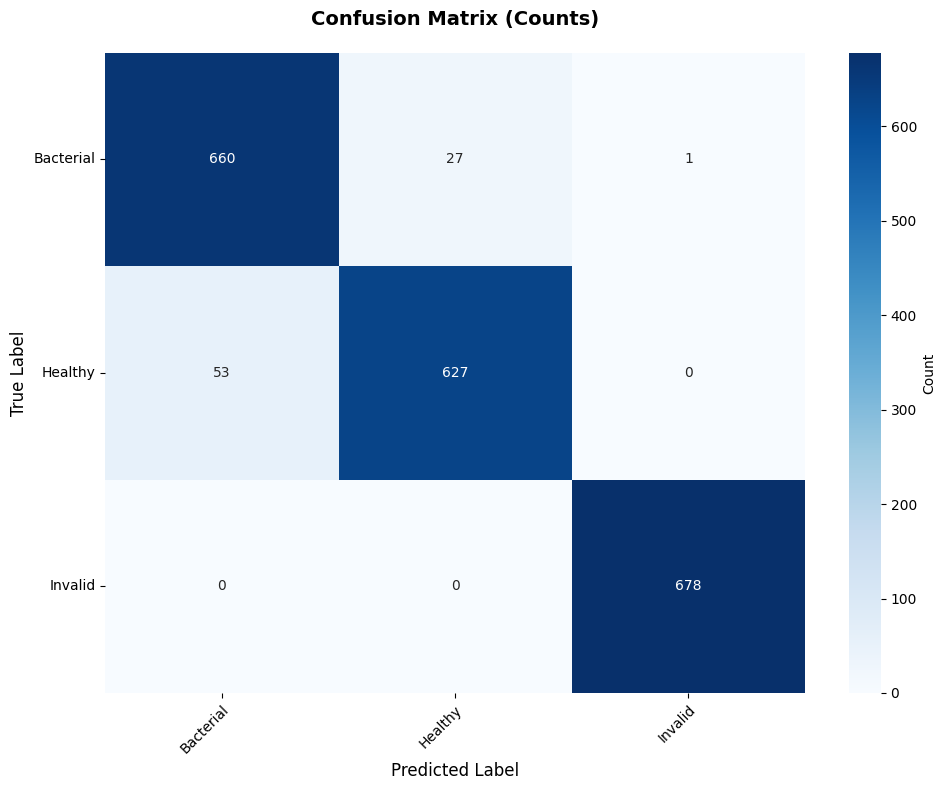

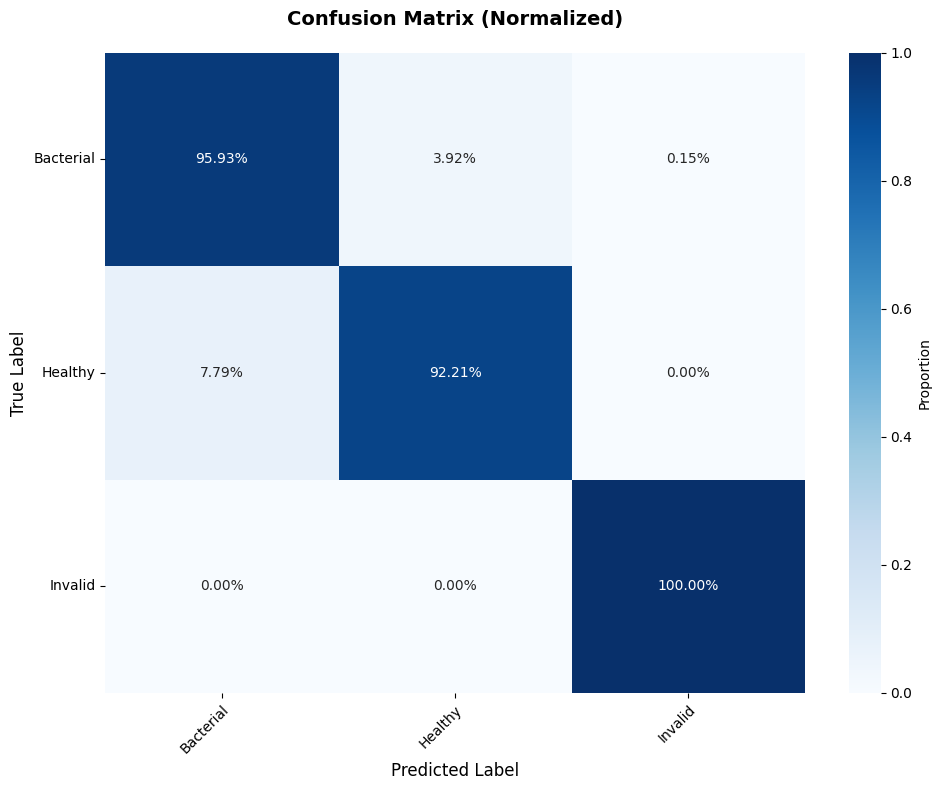

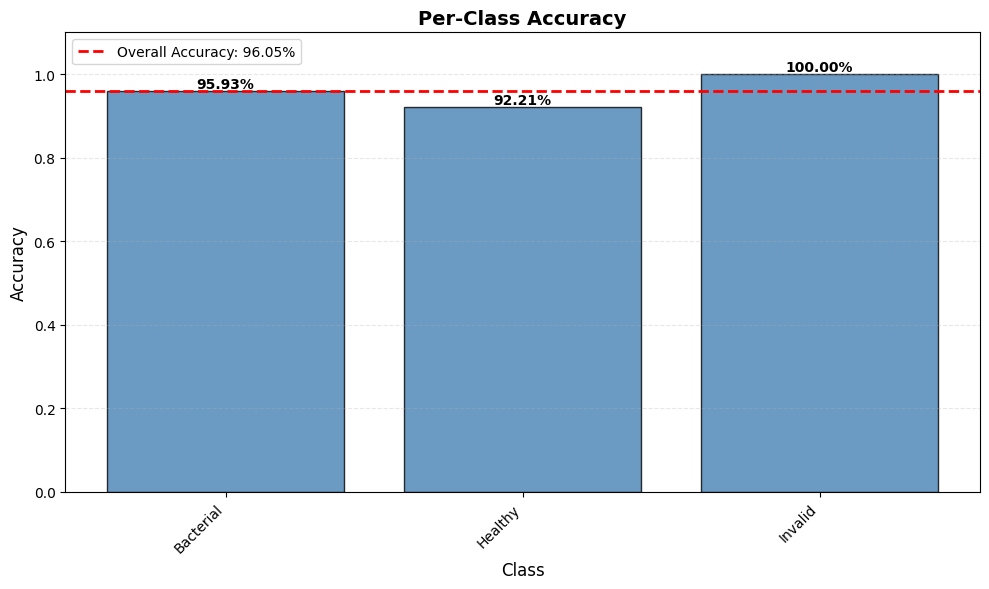

In [49]:
# Plot metrics
results = complete_confusion_analysis(
    predictions=predictions,
    true_labels=true_labels,
    class_names=class_names,
    save_dir='/content'  # Where to save images
)